<a href="https://colab.research.google.com/github/Ermeson23/regional_model_filtering_abductive/blob/main/regional_model_filtering_abductive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Installing the needed library

!pip install xgboost z3-solver

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.7/31.7 MB 39.9 MB/s eta 0:00:00


In [2]:
# Importing needed models

from sklearn.datasets import fetch_openml

from xgboost import XGBClassifier, XGBRegressor

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from z3 import *

import warnings
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=UserWarning, module='sklearn')

import numpy as np

In [3]:
# Loading dataset

heart_dataset = fetch_openml(name='heart-disease', version=1, as_frame=True)
df = heart_dataset.frame

X = df.drop('target', axis=1)
y = df['target']

print(X.shape)
print(y.value_counts())

(303, 13)
target
1.0    165
0.0    138
Name: count, dtype: int64


In [4]:
# Split data into train_set and test_set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [5]:
# Defining both the black and the white box model

teacher_model = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42, eval_metric="logloss")

student_model = DecisionTreeClassifier(random_state=42)

In [6]:
# Training and distillation of the black-box model

teacher_model.fit(X_train, y_train)

y_train_teacher = teacher_model.predict(X_train)

In [7]:
# Training the white-box model through the black-box model

student_model.fit(X_train, y_train_teacher)

DecisionTreeClassifier(random_state=42)

In [8]:
# Geting surrogate's fidelity

y_test_teacher = teacher_model.predict(X_test)
y_test_student = student_model.predict(X_test)

fidelity = accuracy_score(y_test_teacher, y_test_student)
print(f"Surrogate Fidelity: {fidelity * 100:.2f}%")

Surrogate Fidelity: 80.22%


Confusion Matrix of the Fidelity between black-box and white-box model: 



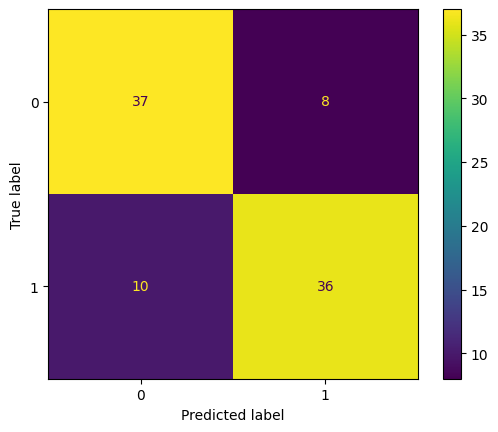

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Confusion Matrix of the Fidelity between black-box and white-box model: \n")
ConfusionMatrixDisplay.from_predictions(y_test_teacher, y_test_student)

plt.show()

In [10]:
# Extracting leaf constraints

def extract_z3_leaf_constraints(tree_model, instance_x, z3_features):
    """
    Extrai o caminho de decisão que a instância percorreu na árvore
    e traduz as regras em uma conjunção (And) do Z3.
    """
    tree = tree_model.tree_
    node_indicator = tree_model.decision_path(instance_x.reshape(1, -1))
    node_index = node_indicator.indices

    leaf_node = node_index[-1]

    z3_rules = []

    for i in range(len(node_index) - 1):
        node_id = node_index[i]
        next_node_id = node_index[i + 1]

        feature_idx = tree.feature[node_id]
        threshold = tree.threshold[node_id]

        if next_node_id == tree.children_left[node_id]:
            z3_rules.append(z3_features[feature_idx] <= float(threshold))
        else:
            z3_rules.append(z3_features[feature_idx] > float(threshold))

    return And(z3_rules)

In [11]:
def is_sufficient_z3(tree_model, instance_x, subset_indices, X_ranges):
    """
    Oráculo Formal via Z3: Prova se o subset é logicamente suficiente.
    """
    s = Solver()
    num_features = len(instance_x)

    z3_features = [Real(f'x_{i}') for i in range(num_features)]

    for idx in subset_indices:
        s.add(z3_features[idx] == float(instance_x[idx]))

    for idx in range(num_features):
        s.add(z3_features[idx] >= float(X_ranges[idx][0]))
        s.add(z3_features[idx] <= float(X_ranges[idx][1]))

    leaf_region = extract_z3_leaf_constraints(tree_model, instance_x, z3_features)

    s.add(Not(leaf_region))

    if s.check() == unsat:
        return True
    else:
        return False

In [12]:
def abductive_explanation_z3(tree_model, x, X_ranges):
    if hasattr(x, "values"):
        x = x.values

    features = list(range(len(x)))
    current = set(features)

    print(f"Starting Formal Abduction. Total features: {len(features)}")
    for f in features:
        trial = current - {f}

        if is_sufficient_z3(tree_model, x, trial, X_ranges):
            print(f" Successfully dropped feature index {f}! (Proved by Z3)")
            current = trial
        else:
            print(f" Cannot drop feature index {f} (Z3 found a counterexample)")

    return list(current)

In [13]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

teacher_scores = cross_val_score(
    teacher_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

student_scores = cross_val_score(
    student_model,
    X,
    y,
    cv=cv,
    scoring="accuracy",
)

print("========================== Teacher's Metrics ==========================")
print("Fold scores:", teacher_scores)
print("Mean Accuracy:", teacher_scores.mean())
print("Std:", teacher_scores.std())

print("\n========================== Student's Metrics ==========================")
print("Fold scores:", student_scores)
print("Mean Accuracy:", student_scores.mean())
print("Std:", student_scores.std())

========================== Teacher's Metrics ==========================
Fold scores: [0.8852459  0.75409836 0.73770492 0.81666667 0.83333333]
Mean Accuracy: 0.8054098360655738
Std: 0.053846186003660944

========================== Student's Metrics ==========================
Fold scores: [0.80327869 0.7704918  0.7704918  0.65       0.65      ]
Mean Accuracy: 0.7288524590163934
Std: 0.06548641722656483


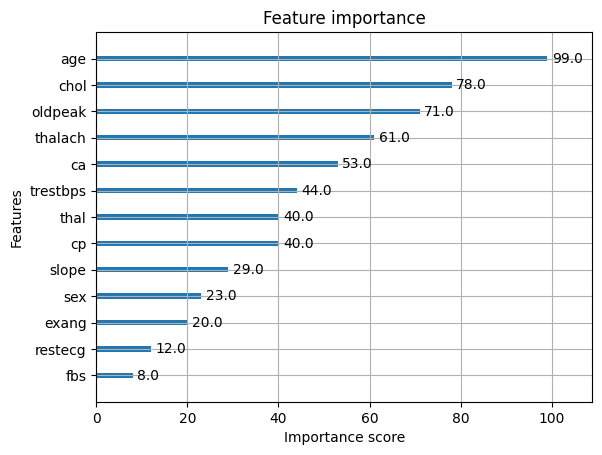

In [14]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(teacher_model)
plt.show()

In [15]:
# Extracting final abductive explanation

feature_names = X_train.columns

X_raw = X_train.values
X_ranges = [(X_raw[:, i].min(), X_raw[:, i].max()) for i in range(X_raw.shape[1])]

patient = X_test.iloc[0]

explanation_features = abductive_explanation_z3(
    tree_model=student_model,
    x=patient,
    X_ranges=X_ranges
)

print("Subset Mínimo Suficiente Formal:", explanation_features)

print("\n--- Final Abductive Explanation ---")
print(f"To keep this specific prediction, the {len(explanation_features)} critical features are:")
for idx in explanation_features:
    print(f" - Feature {idx}: {feature_names[idx]} (Value: {X_test.iloc[0][idx]})")

Starting Formal Abduction. Total features: 13
 Successfully dropped feature index 0! (Proved by Z3)
 Cannot drop feature index 1 (Z3 found a counterexample)
 Cannot drop feature index 2 (Z3 found a counterexample)
 Cannot drop feature index 3 (Z3 found a counterexample)
 Successfully dropped feature index 4! (Proved by Z3)
 Successfully dropped feature index 5! (Proved by Z3)
 Successfully dropped feature index 6! (Proved by Z3)
 Successfully dropped feature index 7! (Proved by Z3)
 Successfully dropped feature index 8! (Proved by Z3)
 Successfully dropped feature index 9! (Proved by Z3)
 Successfully dropped feature index 10! (Proved by Z3)
 Cannot drop feature index 11 (Z3 found a counterexample)
 Successfully dropped feature index 12! (Proved by Z3)
Subset Mínimo Suficiente Formal: [11, 1, 2, 3]

--- Final Abductive Explanation ---
To keep this specific prediction, the 4 critical features are:
 - Feature 11: ca (Value: 1.0)
 - Feature 1: sex (Value: 1.0)
 - Feature 2: cp (Value: 0.0

/tmp/ipykernel_1796/162454255.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f" - Feature {idx}: {feature_names[idx]} (Value: {X_test.iloc[0][idx]})")
